<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day36_Model_Interpretability(SHAP)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete')

Setup complete


In [2]:
!pip install shap -q
import shap
shap.initjs()
print(f'SHAP Version: {shap.__version__}')

SHAP Version: 0.51.0


In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'own_telephone', 'foreign_worker', 'class'
]

df = pd.read_csv(url, sep=' ', names=columns)

print(f"Dataset: {df.shape[0]} loan applications, {df.shape[1]} features")
df.head()

Dataset: 1000 loan applications, 21 features


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df['class'] = (df['class'] == 1).astype(int)

print('Target Distributions:')
print(df['class'].value_counts())
print(f"\nApproval rate: {df['class'].mean()*100:.1f}%")

Target Distributions:
class
1    700
0    300
Name: count, dtype: int64

Approval rate: 70.0%


In [9]:
#Decoding categorical features for interpretability

checking_map = {'A11': '<0', 'A12': '0-200', 'A13': '>=200', 'A14': 'no_account'}
savings_map = {'A61': '<100', 'A62': '100-500', 'A63': '500-1000', 'A64': '>=1000', 'A65': 'unknown'}
employment_map = {'A71': 'unemployed', 'A72': '<1yr', "A73": '1-4yrs', 'A74': '4-7yrs', 'A75': '>=7yrs'}
housing_map = {'A151': 'rent', 'A152': 'own', 'A153': 'free'}

df['checking_status'] =df['checking_status'].map(checking_map).fillna(df['checking_status'])
df['savings_status'] = df['savings_status'].map(savings_map).fillna(df['savings_status'])
df['employment'] = df['employment'].map(employment_map).fillna(df['employment'])
df['housing'] = df['housing'].map(housing_map).fillna(df['housing'])

print(df[['checking_status', 'savings_status', 'employment', 'housing']].head())

  checking_status savings_status employment housing
0              <0        unknown     >=7yrs     own
1           0-200           <100     1-4yrs     own
2      no_account           <100     4-7yrs     own
3              <0           <100     4-7yrs    free
4              <0           <100     1-4yrs    free


In [10]:
x = df.drop('class', axis=1)
y = df['class']

x_encoded = x.copy()
label_encoders = {}

for col in x_encoded.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  x_encoded[col] = le.fit_transform(x_encoded[col].astype(str))
  label_encoders[col] = le

feature_names = x_encoded.columns.tolist()
print(f"Features: {len(feature_names)}")

Features: 20


In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(x_train)}, test: {len(x_test)}")

Train: 800, test: 200


In [13]:
#Training Random Forest for SHAP TreeExplainer
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
rf_model.fit(x_train, y_train)

y_pred = rf_model.predict(x_test)
print(f"Random FOrest Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

Random FOrest Accuracy: 0.7600
Classification Report:
              precision    recall  f1-score   support

      Denied       0.63      0.48      0.55        60
    Approved       0.80      0.88      0.84       140

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



## Part 4: What is SHAP?

**SHAP = SHapley Additive exPlanations**

Based on game theory: How much does each feature contribute to the prediction?

**Key idea:**
- Base value (average prediction)
- + SHAP value for feature 1
- + SHAP value for feature 2
- + ...
- = Final prediction

Calculating SHAP Values

In [14]:
explainer = shap.TreeExplainer(rf_model)

print('Calculating SHAP values...')
shap_values = explainer.shap_values(x_test)

if isinstance(shap_values, list):
  shap_values_class1 = shap_values[1]
else:
  shap_values_class1 = shap_values

print(f"SHAP VAlues shape: {shap_values_class1.shape}")

Calculating SHAP values...
SHAP VAlues shape: (200, 20, 2)


Global Feature Importance

<Figure size 1000x800 with 0 Axes>

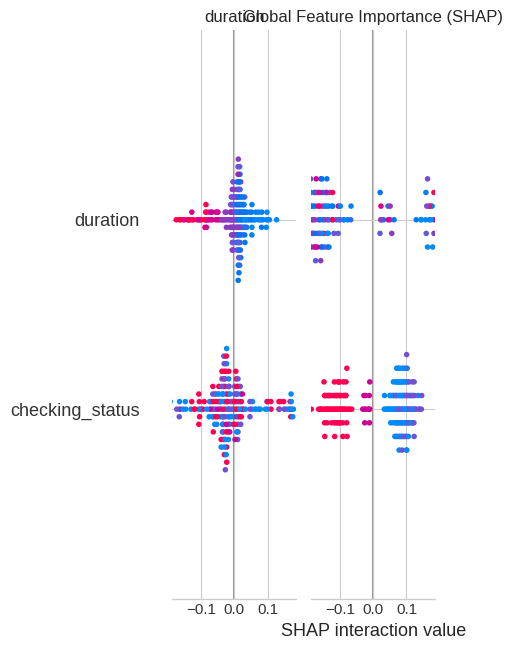

In [15]:
#Plot that shows which features matter the most
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_class1, x_test, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

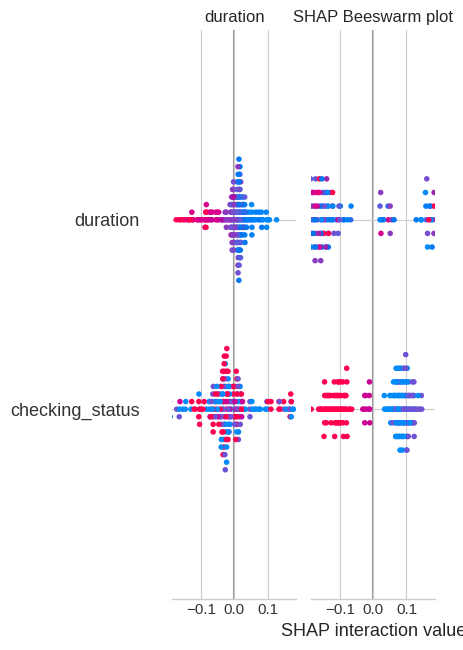

In [16]:
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_class1, x_test, feature_names=feature_names, show=False)
plt.title('SHAP Beeswarm plot')
plt.tight_layout()
plt.show()

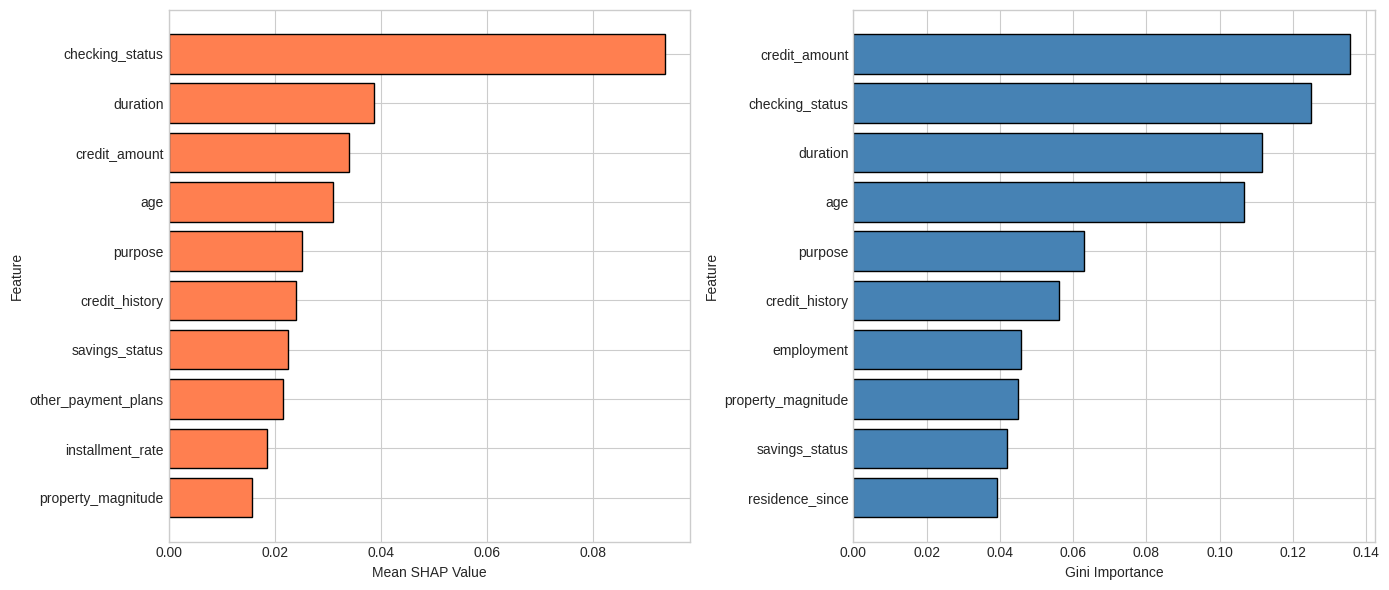

In [19]:
#Comparing with sklearn's feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Shap importance

shap_importance = np.abs(shap_values_class1[:, :, 1]).mean(axis=0)
shap_imp_df = pd.DataFrame({'Feature': feature_names, 'SHAP': shap_importance})
shap_imp_df = shap_imp_df.sort_values('SHAP', ascending=True).tail(10)

axes[0].barh(shap_imp_df['Feature'], shap_imp_df["SHAP"], color='coral', edgecolor='black')
axes[0].set_xlabel('Mean SHAP Value')
axes[0].set_ylabel('Feature')

#sklearn importance
sk_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_})
sk_imp_df = sk_imp_df.sort_values('Importance', ascending=True).tail(10)

axes[1].barh(sk_imp_df['Feature'], sk_imp_df['Importance'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Gini Importance')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

Local Explanations (Individual Predictions)

In [20]:
#Let's find an approved and a denied application
approved_idx = np.where(y_pred == 1)[0][0]
denied_idx = np.where(y_pred == 0)[0][0]

print(f"Approved application index: {approved_idx}")
print(f"Denied application index: {denied_idx}")

Approved application index: 0
Denied application index: 1


In [22]:
#Waterfall plot for Approved application
applicant = x_test.iloc[approved_idx]
print('\nApplicant Details:')
for col in ['checking_status', 'duration', 'credit_amount', 'age', 'employment']:
  val = applicant[col]
  if col in label_encoders and col in x.select_dtypes(include=['object']).columns:
    original_col = x.iloc[x_test.index[approved_idx]][col] if col in x.columns else val
    print(f"     {col}: {original_col}")
  else:
    print(f"     {col}: {val}")


Applicant Details:
     checking_status: 0-200
     duration: 18
     credit_amount: 2427
     age: 42
     employment: >=7yrs


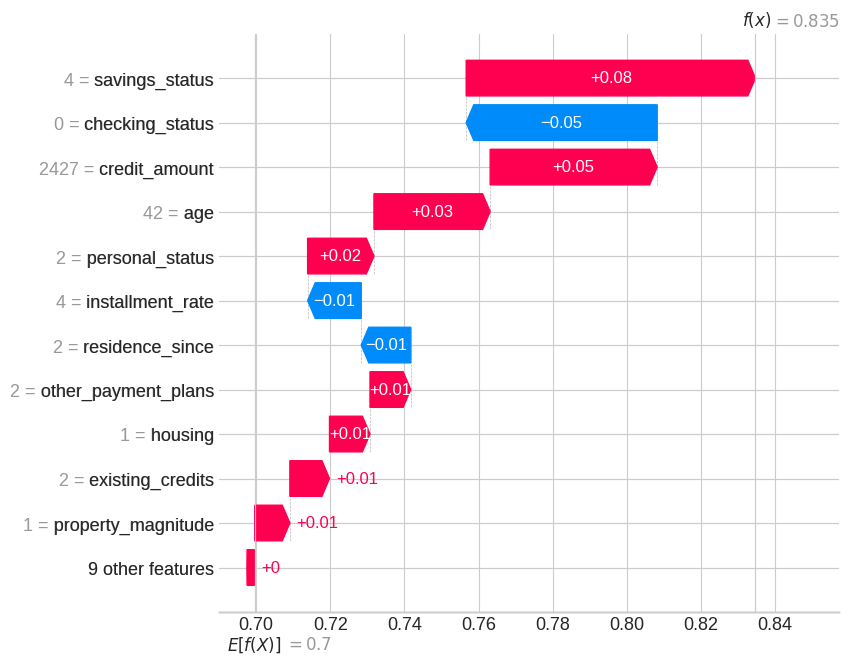

In [26]:
#Waterplot plot
shap.plots.waterfall(shap.Explanation(
    values=shap_values_class1[approved_idx, :, 1], # Select SHAP values for the positive class
    base_values=explainer.expected_value[1], # Always select the expected value for the positive class
    data=x_test.iloc[approved_idx],
    feature_names=feature_names
), max_display=12, show=True)


DENIED Application Explanation:


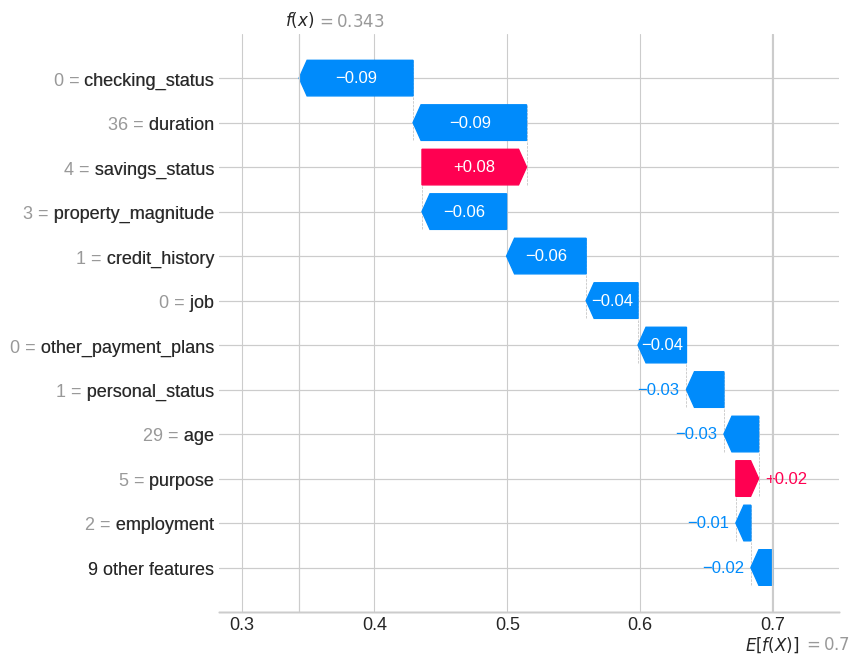

In [28]:
#%%
# Waterfall plot for DENIED application
print("\nDENIED Application Explanation:")
print("="*50)

shap.plots.waterfall(shap.Explanation(
    values=shap_values_class1[denied_idx, :, 1], # Select SHAP values for the positive class
    base_values=explainer.expected_value[1], # Always select the expected value for the positive class
    data=x_test.iloc[denied_idx],
    feature_names=feature_names
), max_display=12, show=True)

Force Plot (visual explanation):


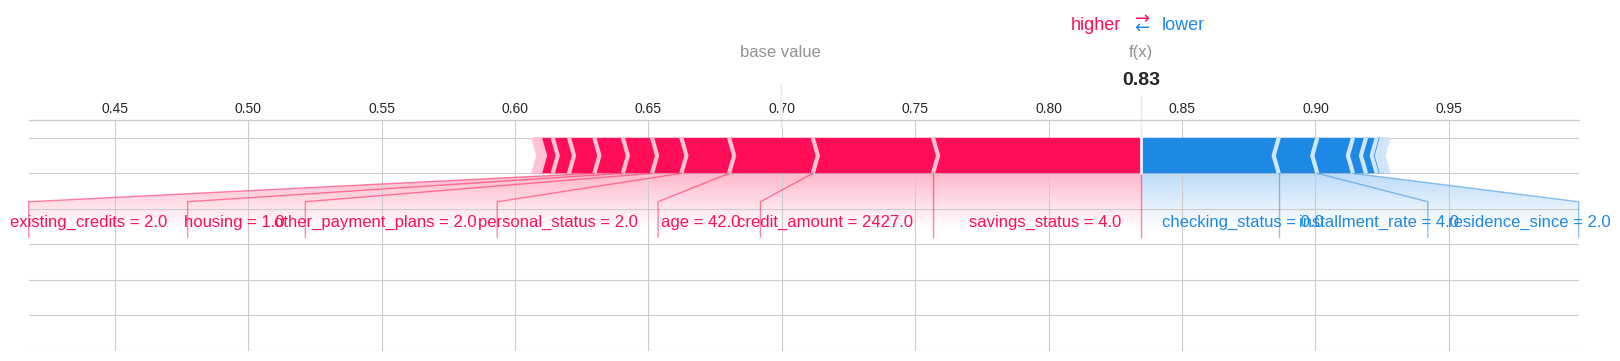

In [31]:
# Force plot for single prediction
print("Force Plot (visual explanation):")
shap.plots.force(
    base_value=explainer.expected_value[1], # Base value for the positive class
    shap_values=shap_values_class1[approved_idx, :, 1], # SHAP values for the approved_idx, positive class
    features=x_test.iloc[approved_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

Dependence Plots

<Figure size 1000x600 with 0 Axes>

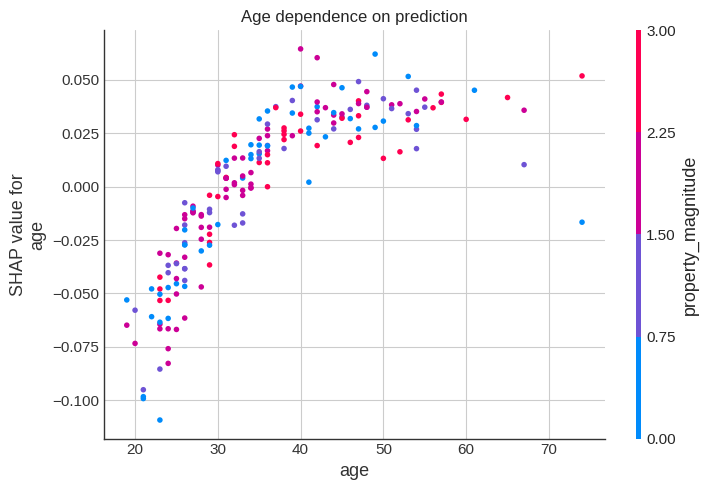

In [33]:
# How does a feature affect a prediction
#Age dependence
plt.figure(figsize=(10, 6))
shap.dependence_plot('age', shap_values_class1[:, :, 1], x_test, feature_names=feature_names, show=False)
plt.title('Age dependence on prediction')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

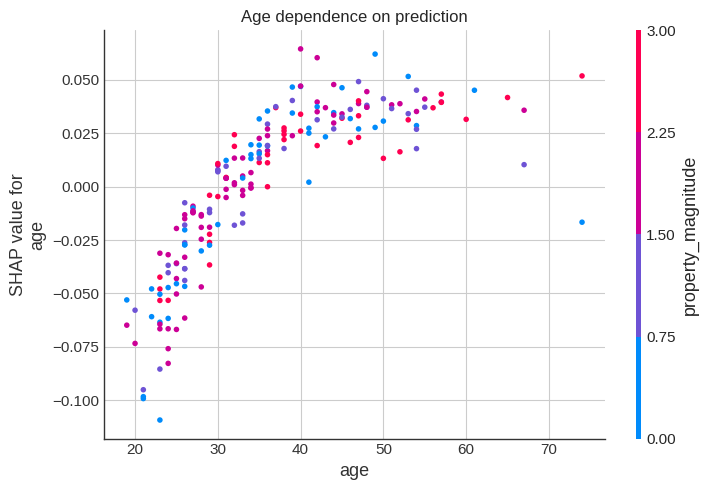

In [35]:
#credit amount depondence
plt.figure(figsize=(10, 6))
shap.dependence_plot('age', shap_values_class1[:, :, 1], x_test, feature_names=feature_names, show=False)
plt.title('Age dependence on prediction')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

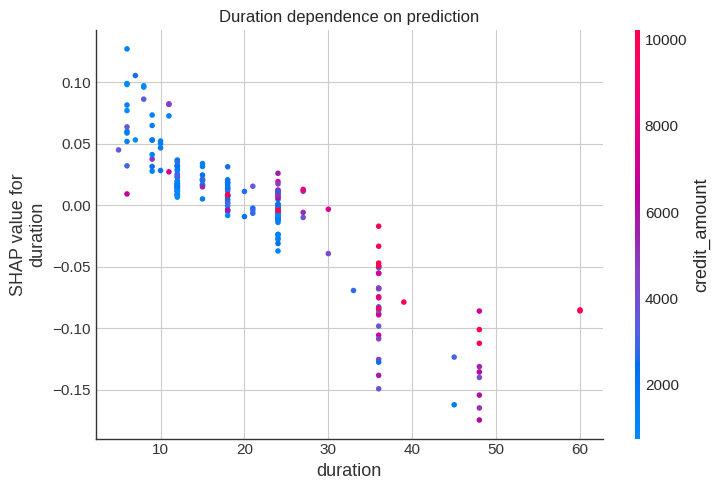

In [37]:
#Duration dependence
plt.figure(figsize=(10, 6))
shap.dependence_plot('duration', shap_values_class1[:, :, 1], x_test, feature_names=feature_names, show=False)
plt.title('Duration dependence on prediction')
plt.tight_layout()
plt.show()

Multi-sample force plot

In [40]:
#Shows pattern across many predictions
sample_size = 100
sample_idx = np.random.choice(len(x_test), sample_size, replace=False)

shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[sample_idx, :, 1],
    x_test.iloc[sample_idx],
    feature_names=feature_names,
)

In [43]:
# Compare SHAP across different models
# Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(x_train, y_train)

# SHAP for Gradient Boosting
gb_explainer = shap.TreeExplainer(gb_model)
gb_shap_values = gb_explainer.shap_values(x_test)

print(f"GB Accuracy: {accuracy_score(y_test, gb_model.predict(x_test)):.4f}")

GB Accuracy: 0.7850


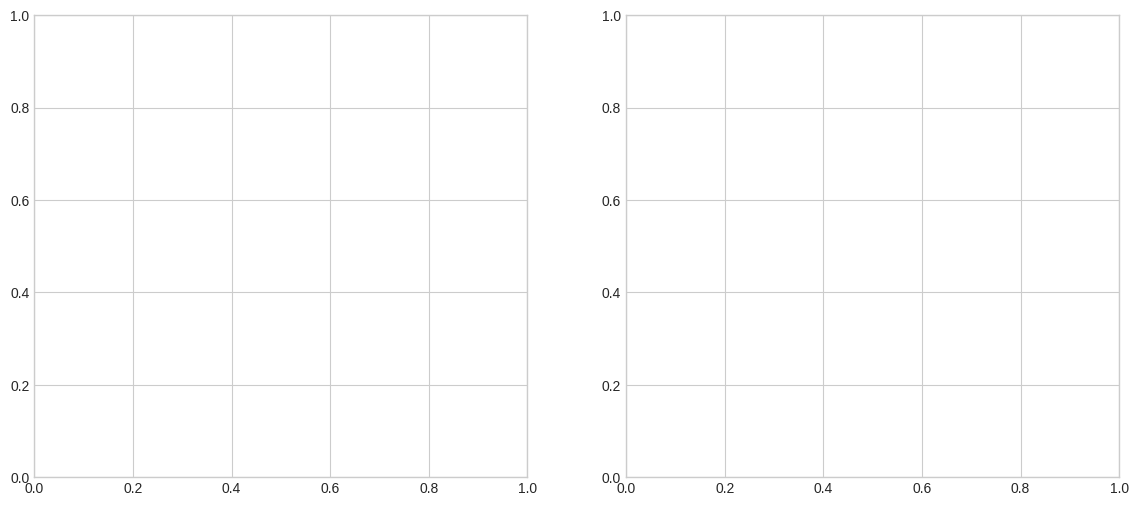

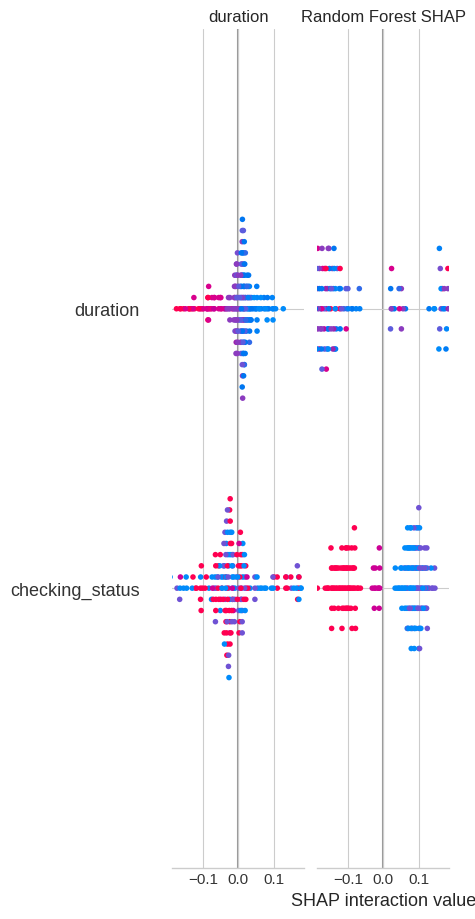

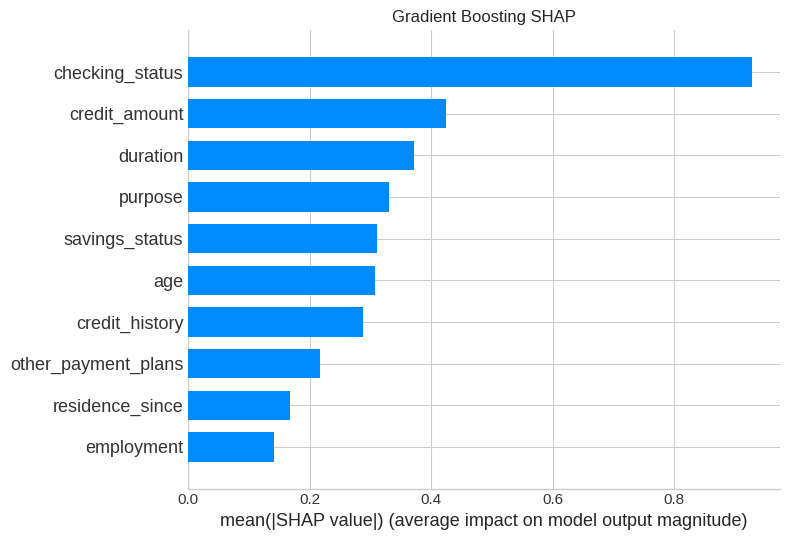

In [45]:
# Compare feature importance between models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest SHAP
shap.summary_plot(shap_values_class1, x_test, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=10)
axes[0] = plt.gca()
axes[0].set_title('Random Forest SHAP')

plt.figure(figsize=(10, 6))
# Gradient Boosting SHAP
shap.summary_plot(gb_shap_values, x_test, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=10)
plt.title('Gradient Boosting SHAP')
plt.tight_layout()
plt.show()

## Summary


| Plot | Use For |
|------|--------|
| Summary (bar) | Global feature ranking |
| Summary (beeswarm) | Importance + direction |
| Waterfall | Single prediction breakdown |
| Force | Visual single explanation |
| Dependence | Feature effect curves |

### Key Takeaways

1. **SHAP provides consistent, fair explanations** (based on game theory)
2. **Global importance** shows what matters overall
3. **Local explanations** answer "why this prediction?"
4. **Dependence plots** reveal non-linear effects
5. **Essential for regulated industries** (finance, healthcare)

### When to Use SHAP

- Explaining model to stakeholders
- Debugging unexpected predictions
- Compliance and audit requirements
- Feature engineering insights
- Fairness analysis